In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path("/kaggle/input/datasets/mateuszbielowka/images-gt/images")
GT_DIR = Path("/kaggle/input/datasets/mateuszbielowka/images-gt/images_gt2")

print(f"Images directory exists: {IMAGES_DIR.exists()} \nGT directory exists: {GT_DIR.exists()}")
print(f"Images count: {len(list(IMAGES_DIR.glob('*.png')))} \nGT images count: {len(list(GT_DIR.glob('*.png')))}")

Images directory exists: True 
GT directory exists: True
Images count: 247 
GT images count: 94


In [22]:
image_files = {p.name for p in IMAGES_DIR.glob("*.png")}
gt_files = {p.name for p in GT_DIR.glob("*.png")}
common_names = sorted(image_files & gt_files)

print(f"\nZnalezione pary obraz-GT: {len(common_names)} \nPrzykłady: {common_names[:5]}")


Znalezione pary obraz-GT: 94 
Przykłady: ['1.png', '2.png', '20260326202254.png', '20260326202321.png', '20260409194355.png']


In [23]:
def extract_red_mask(gt_img_bgr):
    blue = gt_img_bgr[:, :, 0].astype(np.int16)
    green = gt_img_bgr[:, :, 1].astype(np.int16)
    red = gt_img_bgr[:, :, 2].astype(np.int16)
    
    red_pixels = (np.abs(red - 237) <= 1) & (np.abs(green - 28) <= 1) & (np.abs(blue - 36) <= 1)
    return red_pixels.astype(np.uint8)

if common_names:
    test_name = common_names[0]
    print(f"Testowanie na: {test_name}")
    source = cv2.imread(str(IMAGES_DIR / test_name), cv2.IMREAD_GRAYSCALE)
    gt = cv2.imread(str(GT_DIR / test_name), cv2.IMREAD_COLOR)
    red_mask = extract_red_mask(gt)
    gt_columns = red_mask.any(axis=0)
    print(f"Rozmiar obrazu źródłowego: {source.shape}     Rozmiar GT: {gt.shape}")
    print(f"Liczba kolumn z GT: {gt_columns.sum()}        Procent kolumn do rozdzielenia: {100*gt_columns.sum()/gt_columns.shape[0]:.1f}%")

Testowanie na: 1.png
Rozmiar obrazu źródłowego: (107, 1141)     Rozmiar GT: (107, 1141, 3)
Liczba kolumn z GT: 334        Procent kolumn do rozdzielenia: 29.3%


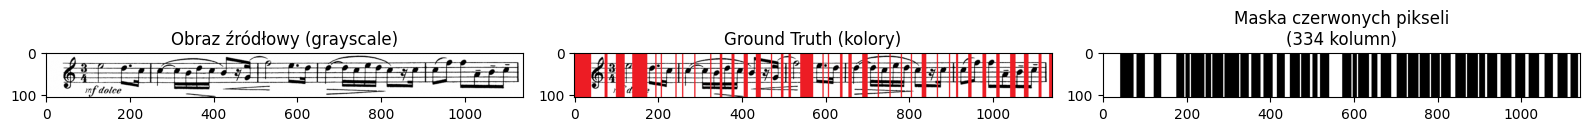


Plik: 1.png


In [24]:
if common_names:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    test_name = common_names[0]
    source = cv2.imread(str(IMAGES_DIR / test_name), cv2.IMREAD_GRAYSCALE)
    gt = cv2.imread(str(GT_DIR / test_name), cv2.IMREAD_COLOR)
    red_mask = extract_red_mask(gt)
    gt_columns = red_mask.any(axis=0)
    
    axes[0].imshow(source, cmap='gray')
    axes[0].set_title("Obraz źródłowy (grayscale)")
    axes[1].imshow(cv2.cvtColor(gt, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Ground Truth (kolory)")
    col_viz = np.zeros_like(red_mask)
    col_viz[:, gt_columns] = 255
    axes[2].imshow(col_viz, cmap='gray')
    axes[2].set_title(f"Maska czerwonych pikseli\n({gt_columns.sum()} kolumn)")
    plt.tight_layout(); plt.show()
    print(f"\nPlik: {test_name}")

In [25]:
def extract_random_patches(source, gt, patch_height=107, patch_width=107, num_patches=5):
    patches = []
    h, w = source.shape[:2]
    
    if h < patch_height or w < patch_width:
        return patches
    
    for _ in range(num_patches):
        y = np.random.randint(0, h - patch_height + 1)
        x = np.random.randint(0, w - patch_width + 1)
        source_patch = source[y:y+patch_height, x:x+patch_width]
        gt_patch = gt[y:y+patch_height, x:x+patch_width]
        patches.append((source_patch, gt_patch))
    return patches

if common_names:
    test_name = common_names[0]
    source = cv2.imread(str(IMAGES_DIR / test_name), cv2.IMREAD_GRAYSCALE)
    gt = cv2.imread(str(GT_DIR / test_name), cv2.IMREAD_COLOR)
    red_mask = extract_red_mask(gt)
    
    test_patches = extract_random_patches(source, red_mask, num_patches=3)
    print(f"Pobrano {len(test_patches)} wycinków z rozmiarem: {test_patches[0][0].shape if test_patches else 'brak'}")

Pobrano 3 wycinków z rozmiarem: (107, 107)


In [26]:
np.random.seed(42); patches_per_image = 50
training_patches = []

print(f"Zbieranie wycinków ze {len(common_names)} par obrazów... \nPo {patches_per_image} wycinków z każdego obrazu")
print("-" * 60)

for idx, name in enumerate(common_names):
    source = cv2.imread(str(IMAGES_DIR / name), cv2.IMREAD_GRAYSCALE)
    gt = cv2.imread(str(GT_DIR / name), cv2.IMREAD_COLOR)
    
    if source is None or gt is None:
        continue
    
    red_mask = extract_red_mask(gt)
    patches = extract_random_patches(source, red_mask, num_patches=patches_per_image)
    training_patches.extend(patches)
    
    if (idx + 1) % 10 == 0:
        print(f"  [{idx+1}/{len(common_names)}] Razem wycinki: {len(training_patches)}")

print("-" * 60)
print(f"  Razem zebranych wycinków: {len(training_patches)}\n  Wymiary każdego wycinka: 107 x 107 px (H x W)")

Zbieranie wycinków ze 94 par obrazów... 
Po 50 wycinków z każdego obrazu
------------------------------------------------------------
  [10/94] Razem wycinki: 250
  [20/94] Razem wycinki: 250
  [30/94] Razem wycinki: 400
  [40/94] Razem wycinki: 450
  [50/94] Razem wycinki: 450
  [60/94] Razem wycinki: 550
  [70/94] Razem wycinki: 650
  [80/94] Razem wycinki: 900
  [90/94] Razem wycinki: 1350
------------------------------------------------------------
  Razem zebranych wycinków: 1500
  Wymiary każdego wycinka: 107 x 107 px (H x W)


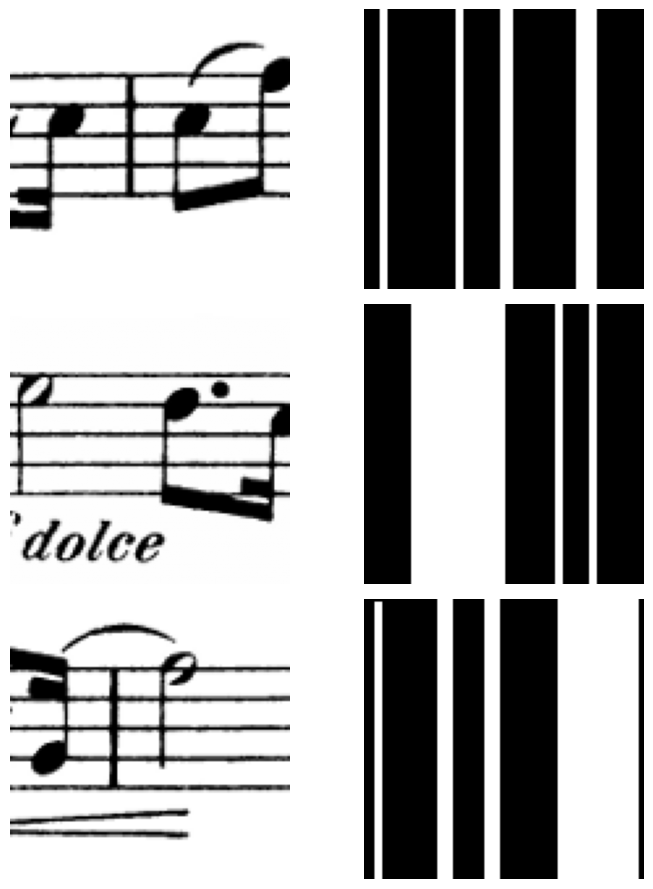


Wyświetlono 3 przykładowych par wycinków 
Wymiary: 107 x 107 px (H x W)


In [27]:
num_show = min(3, len(training_patches))
fig, axes = plt.subplots(num_show, 2, figsize=(8, 3*num_show))

if num_show == 1:
    axes = axes.reshape(1, -1)
for i in range(num_show):
    source_patch, gt_patch = training_patches[i]
    axes[i, 0].imshow(source_patch, cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(gt_patch, cmap='gray')
    axes[i, 1].axis('off')
plt.tight_layout(); plt.show()

print(f"\nWyświetlono {num_show} przykładowych par wycinków \nWymiary: 107 x 107 px (H x W)")

In [28]:
print("\n " + "="*60, "\n STATYSTYKI DATASETU TRENINGOWEGO\n", "="*60)
print(f" Całkowita liczba wycinków: {len(training_patches)}\n Wymiary każdego wycinka: 107 x 214 px")
print(f" Liczba par obrazów źródłowych: {len(common_names)}\n Średnia wycinków na obraz: {len(training_patches) / len(common_names):.1f}")

gt_statistics = []
for source_patch, gt_patch in training_patches:
    gt_columns = gt_patch.any(axis=0)
    gt_statistics.append(gt_columns.sum())

gt_stats = np.array(gt_statistics)
print(f"\n Statystyki kolumn do rozdzielenia w wycinkach:\n  Średnia: {gt_stats.mean():.1f} kolumn/wycinek\n  Min: {gt_stats.min()} kolumn\n  Max: {gt_stats.max()} kolumn")
print(f"  Procent wycinków bez kolumn: {100 * (gt_stats == 0).sum() / len(gt_stats):.1f}%\n", "="*60)


 STATYSTYKI DATASETU TRENINGOWEGO
 Całkowita liczba wycinków: 1500
 Wymiary każdego wycinka: 107 x 214 px
 Liczba par obrazów źródłowych: 94
 Średnia wycinków na obraz: 16.0

 Statystyki kolumn do rozdzielenia w wycinkach:
  Średnia: 35.5 kolumn/wycinek
  Min: 0 kolumn
  Max: 107 kolumn
  Procent wycinków bez kolumn: 6.7%


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

X = np.array([patch[0] for patch in training_patches], dtype=np.float32) / 255.0
y = np.array([patch[1] for patch in training_patches], dtype=np.float32)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"  X: ({X.shape[0]}, {X.shape[1]}, {X.shape[2]}) = (samples, height, width)")
print(f"  y: ({y.shape[0]}, {y.shape[1]}, {y.shape[2]}) = (samples, height, width)")

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"\nPodział danych:")
print(f"  Train: {X_train.shape[0]} samples ({100*X_train.shape[0]/len(X):.1f}%)")
print(f"  Val:   {X_val.shape[0]} samples ({100*X_val.shape[0]/len(X):.1f}%)")
print(f"  Test:  {X_test.shape[0]} samples ({100*X_test.shape[0]/len(X):.1f}%)")

Dataset shape: X=(1500, 107, 107), y=(1500, 107, 107)
  X: (1500, 107, 107) = (samples, height, width)
  y: (1500, 107, 107) = (samples, height, width)

Podział danych:
  Train: 900 samples (60.0%)
  Val:   300 samples (20.0%)
  Test:  300 samples (20.0%)


In [30]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(SimpleUNet, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        ) 
        self.upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.out = nn.Conv2d(32, out_channels, kernel_size=1)
    
    def forward(self, x):
        enc1 = self.enc1(x)
        x = self.pool1(enc1)
        enc2 = self.enc2(x)
        x = self.pool2(enc2)
        x = self.bottleneck(x)
        x = self.upconv2(x)

        if x.shape[2:] != enc2.shape[2:]:
            x = torch.nn.functional.interpolate(x, size=enc2.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)
        
        x = self.upconv1(x)
        if x.shape[2:] != enc1.shape[2:]:
            x = torch.nn.functional.interpolate(x, size=enc1.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)
        x = self.out(x)
        return x

class PatchDataset(Dataset):
    def __init__(self, images, masks, raw_images):

        self.images = torch.from_numpy(images).unsqueeze(1).float()
        self.masks  = torch.from_numpy(masks).unsqueeze(1).float()
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

raw_all = np.array(
    [patch[0] for patch in training_patches], dtype=np.uint8
)

In [31]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(training_patches))
idx_temp, idx_test = train_test_split(indices, test_size=0.2, random_state=42)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=42)

raw_train = raw_all[idx_train]; raw_val = raw_all[idx_val]; raw_test = raw_all[idx_test]

train_ds = PatchDataset(X_train, y_train, raw_train)
val_ds   = PatchDataset(X_val,   y_val,   raw_val)
test_ds  = PatchDataset(X_test,  y_test,  raw_test)

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
print(f"DataLoaders created with batch_size={batch_size}")

DataLoaders created with batch_size=16


In [32]:
class ResNetUNet(nn.Module):

    def __init__(self, in_channels=1, out_channels=1):
        super(ResNetUNet, self).__init__()
        
        self.enc1 = self._residual_block(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = self._residual_block(32, 64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.enc3 = self._residual_block(64, 128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.bottleneck = self._residual_block(128, 256)
        
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = self._residual_block(256, 128)
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = self._residual_block(128, 64)
        self.upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = self._residual_block(64, 32)

        self.out = nn.Conv2d(32, out_channels, kernel_size=1)
    
    def _residual_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
        )
    
    def forward(self, x):
        enc1 = self.enc1(x)
        x = self.pool1(enc1)
        enc2 = self.enc2(x)
        x = self.pool2(enc2)
        enc3 = self.enc3(x)
        x = self.pool3(enc3)
        x = self.bottleneck(x)
        x = self.upconv3(x)
        if x.shape[2:] != enc3.shape[2:]:
            x = torch.nn.functional.interpolate(x, size=enc3.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc3], dim=1)
        x = self.dec3(x)
        x = self.upconv2(x)
        if x.shape[2:] != enc2.shape[2:]:
            x = torch.nn.functional.interpolate(x, size=enc2.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)
        x = self.upconv1(x)
        if x.shape[2:] != enc1.shape[2:]:
            x = torch.nn.functional.interpolate(x, size=enc1.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)
        x = self.out(x)
        return x


MODEL_CHOICE = "SimpleUNet"  # opcje "SimpleUNet" lub "ResNetUNet"

if MODEL_CHOICE not in ["SimpleUNet", "ResNetUNet"]:
    raise ValueError(f"Unknown model: {MODEL_CHOICE}")
print(f"Wybrany model: {MODEL_CHOICE}")

Wybrany model: SimpleUNet


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu"); print(f"Using device: {device}")

if MODEL_CHOICE == "SimpleUNet":
    model = SimpleUNet(in_channels=1, out_channels=1).to(device)
elif MODEL_CHOICE == "ResNetUNet":
    model = ResNetUNet(in_channels=1, out_channels=1).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 40
history = {'train_loss': [], 'val_loss': []}

print("\n " + "="*60, "\n TRENING MODELU\n", "="*60)

for epoch in range(1, epochs + 1):

    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    
    train_loss /= len(train_ds)
    history['train_loss'].append(train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)
    
    val_loss /= len(val_ds)
    history['val_loss'].append(val_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Trening zakończony")


Using device: cuda

 TRENING MODELU
Epoch  1/40 | Train Loss: 0.6236 | Val Loss: 0.5944
Epoch  5/40 | Train Loss: 0.4700 | Val Loss: 0.4663
Epoch 10/40 | Train Loss: 0.4188 | Val Loss: 0.4188
Epoch 15/40 | Train Loss: 0.3853 | Val Loss: 0.3896
Epoch 20/40 | Train Loss: 0.3621 | Val Loss: 0.3776
Epoch 25/40 | Train Loss: 0.3412 | Val Loss: 0.3692
Epoch 30/40 | Train Loss: 0.3181 | Val Loss: 0.3633
Epoch 35/40 | Train Loss: 0.2983 | Val Loss: 0.3606
Epoch 40/40 | Train Loss: 0.2782 | Val Loss: 0.3570
Trening zakończony


In [34]:
def masks_to_columns(mask_batch, threshold_ratio=0.4):
    col_ratio = mask_batch.mean(axis=2)
    return (col_ratio > threshold_ratio).astype(np.uint8)

In [35]:
threshold_param = 0.2; ratio_param = 0.42
def evaluate_model(model, loader, device, threshold=threshold_param):
    model.eval()
    all_preds = []; all_targets = []
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > threshold).float()
            pred_cols = masks_to_columns(preds.cpu().numpy(), threshold_ratio=ratio_param)
            target_cols = masks_to_columns(masks.cpu().numpy(), threshold_ratio=ratio_param)
            
            all_preds.append(pred_cols); all_targets.append(target_cols)

    preds = np.concatenate(all_preds).flatten(); targets = np.concatenate(all_targets).flatten()
    return preds, targets

val_preds, val_targets = evaluate_model(model, val_loader, device)
test_preds, test_targets = evaluate_model(model, test_loader, device)

val_accuracy = accuracy_score(val_targets, val_preds)
val_precision = precision_score(val_targets, val_preds, zero_division=0)
val_recall = recall_score(val_targets, val_preds, zero_division=0)
val_f1 = f1_score(val_targets, val_preds, zero_division=0)

test_accuracy = accuracy_score(test_targets, test_preds)
test_precision = precision_score(test_targets, test_preds, zero_division=0)
test_recall = recall_score(test_targets, test_preds, zero_division=0)
test_f1 = f1_score(test_targets, test_preds, zero_division=0)

print("\n" + "="*60)
print("METRYKI WALIDACYJNE")
print("="*60)
print(f"Accuracy:  {val_accuracy:.4f} \nPrecision: {val_precision:.4f} \nRecall:    {val_recall:.4f} \nF1-Score:  {val_f1:.4f}")

print("\n" + "="*60)
print("METRYKI TESTOWE")
print("="*60)
print(f"Accuracy:  {test_accuracy:.4f} \nPrecision: {test_precision:.4f} \nRecall:    {test_recall:.4f} \nF1-Score:  {test_f1:.4f}")
print("="*60)


METRYKI WALIDACYJNE
Accuracy:  0.9156 
Precision: 0.9089 
Recall:    0.8421 
F1-Score:  0.8742

METRYKI TESTOWE
Accuracy:  0.9126 
Precision: 0.8929 
Recall:    0.8073 
F1-Score:  0.8480


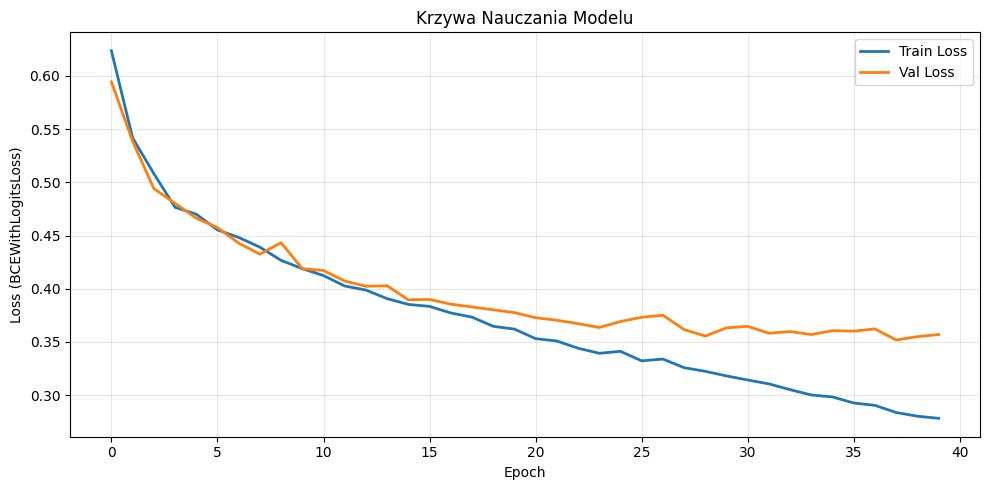

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (BCEWithLogitsLoss)')
ax.set_title('Krzywa Nauczania Modelu')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

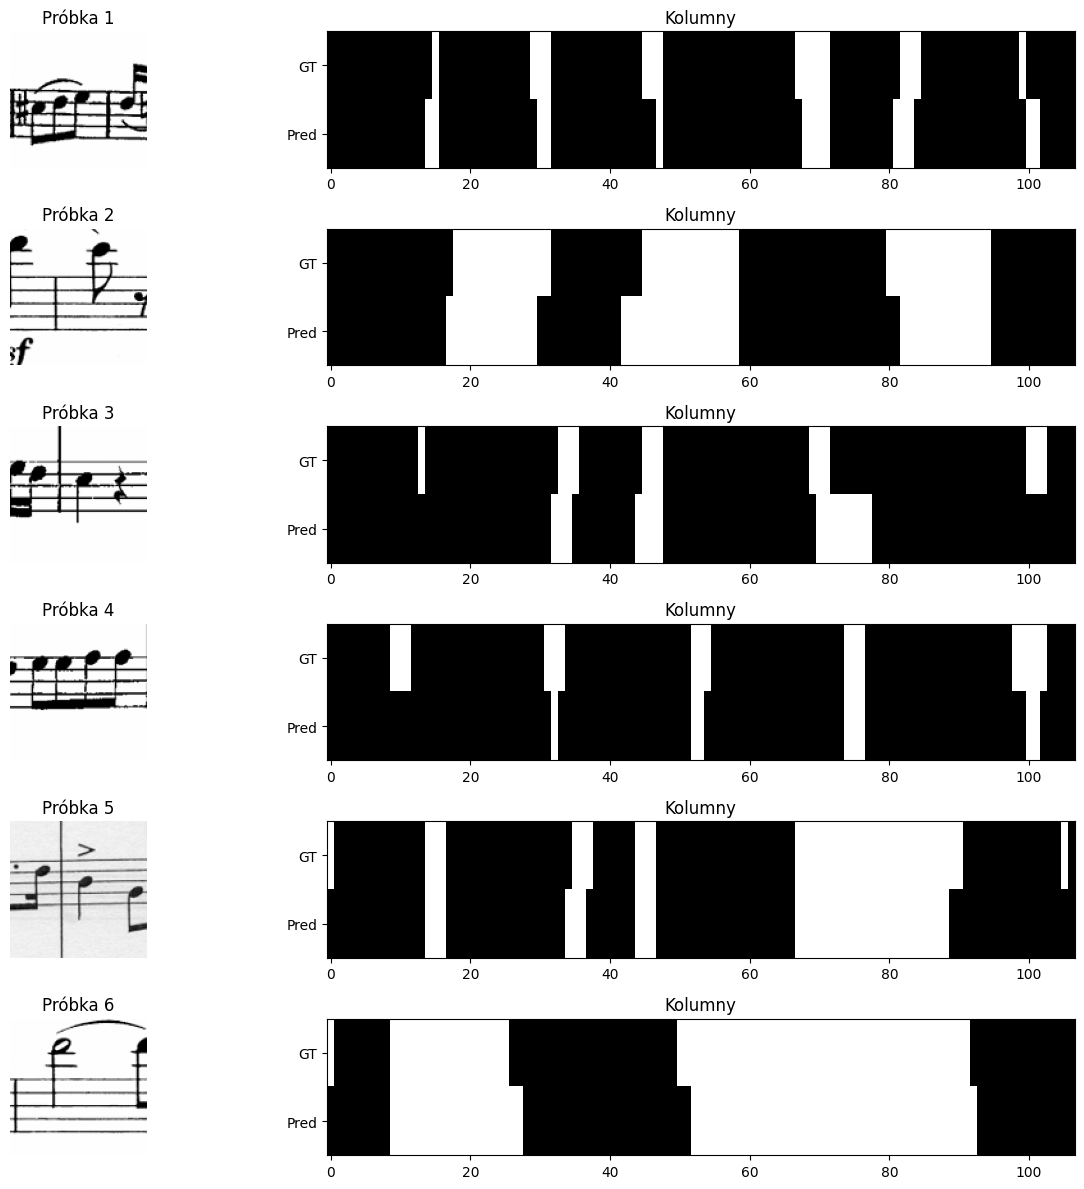

In [38]:
def mask_to_columns(mask, threshold_ratio=ratio_param):
    return (mask.mean(axis=0) > threshold_ratio).astype(np.uint8)

model.eval()
num_examples = 6

fig, axes = plt.subplots(num_examples, 2, figsize=(14, 2*num_examples))
with torch.no_grad():
    shown = 0
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = (outputs > threshold_param).float()

        for j in range(images.shape[0]):
            if shown >= num_examples:
                break

            img = images[j, 0].cpu().numpy()
            gt_mask = masks[j, 0].cpu().numpy()
            pred_mask = preds[j, 0].cpu().numpy()
            gt_cols = mask_to_columns(gt_mask)
            pred_cols = mask_to_columns(pred_mask)

            axes[shown, 0].imshow(img, cmap="gray")
            axes[shown, 0].set_title(f"Próbka {shown+1}")
            axes[shown, 0].axis("off")
            axes[shown, 1].imshow(np.vstack([gt_cols, pred_cols]), aspect="auto", cmap="gray")
            axes[shown, 1].set_yticks([0, 1])
            axes[shown, 1].set_yticklabels(["GT", "Pred"])
            axes[shown, 1].set_title("Kolumny")
            shown += 1

        if shown >= num_examples:
            break
plt.tight_layout(); plt.show()

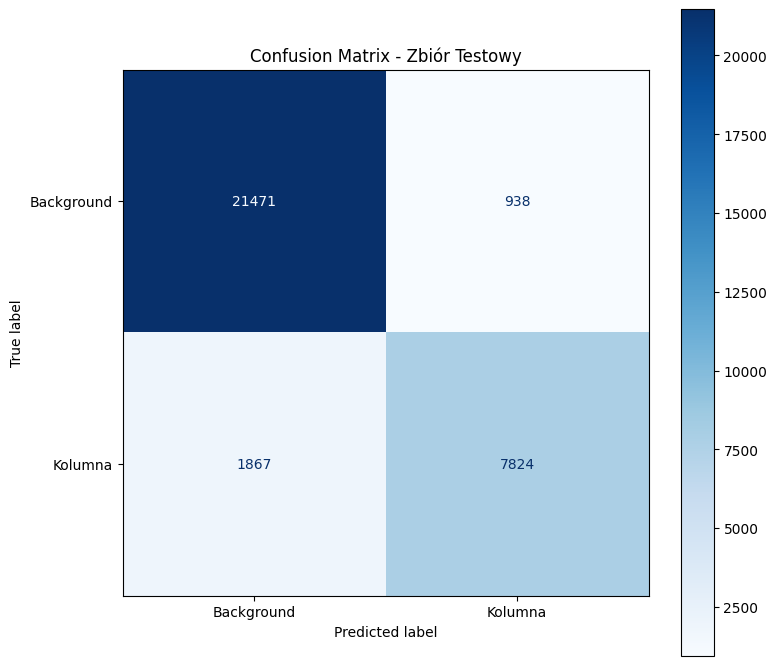

True Negatives (TN):  21471 
False Positives (FP): 938 
False Negatives (FN): 1867 
True Positives (TP):  7824


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_targets, test_preds)

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Background', 'Kolumna'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Zbiór Testowy')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print("="*60)
print(f"True Negatives (TN):  {tn} \nFalse Positives (FP): {fp} \nFalse Negatives (FN): {fn} \nTrue Positives (TP):  {tp}")
print("="*60)